# Social Media Usage and Mental Health: Can Online Habits Predict Treatment-Seeking Behavior?

**Author:** Navi Chawla
**Course:** CMPS 4790/6790 – Data Science, Tulane University
**Professor:** Dr. Faust
**Milestone:** 2 — Additional ETL + Exploratory Data Analysis + Model Proposal
**Date:** March 2026

🔗 **[View this notebook on GitHub Pages](https://navichawla48.github.io/)**

---

## Project Overview

Mental health has become one of the most pressing public health issues of the 21st century, and social media usage has grown explosively over the same period. But how connected are these two trends?

This tutorial investigates whether **social media habits** — including daily usage time, platform preferences, and self-reported effects on mood and focus — can **predict whether someone seeks professional mental health treatment**.

Since Milestone 1, we have significantly expanded the project in three areas:

1. Completed and deepened ETL on both core datasets and added a third supplementary dataset (WHO country-level mental health statistics) to capture structural access to care as a predictor variable.

2. Expanded our EDA with 7 visualizations that reveal patterns directly motivating our two proposed models.

3. Proposed two concrete classification models — Logistic Regression and Random Forest — with clear independent/dependent variables and methodology.

**Core Question:** Can demographic features, social media behavioral indicators (anxiety, depression, distraction scores), and workplace variables predict whether a tech worker will seek professional mental health treatment?


## Datasets

### Dataset 1: OSMI Mental Health in Tech Survey (2014)

- **Source:** [Kaggle – OSMI Mental Health in Tech Survey (2014)](https://www.kaggle.com/datasets/osmi/mental-health-in-tech-survey)
- **Description:** A survey of approximately 1,260 tech industry workers about their mental health attitudes, workplace environment, and whether they have sought treatment. Key columns include `Age`, `Gender`, `Country`, `treatment` (our target variable), `work_interfere`, `benefits`, and `remote_work`.
- **Format:** CSV, 27 columns
- **Data collection:** Conducted by Open Sourcing Mental Illness (OSMI), a nonprofit. Publicly available under Creative Commons Attribution license.
- **Why 2014 and not a newer year?** Newer OSMI surveys exist on Kaggle (2016, 2017, 2019, 2020, 2021, 2023). However, the 2014 edition is the most appropriate for this project for three specific reasons:

  1. **Sample size:** The 2014 dataset is the largest single-year OSMI survey with ~1,260 responses. Later years saw significantly smaller samples — the 2020 survey had approximately 180 responses — which would reduce statistical power for our classification models.

  2. **Temporal alignment with Dataset 2:** Using a 2021 or 2023 OSMI dataset alongside a 2022 social media survey would introduce a temporal mismatch, potentially conflating shifts in treatment-seeking attitudes over time with the social media signal we are trying to isolate.

  3. **Benchmark comparability:** The 2014 survey is the most widely cited in the academic literature on mental health in tech, making our results more directly comparable to prior work.

  A valuable extension for the final deliverable would be to incorporate the 2016–2019 OSMI waves to study whether treatment-seeking trends have shifted over time.

### Dataset 2: Social Media & Mental Health Survey (2022)

- **Source:** [Kaggle – Social Media and Mental Health](https://www.kaggle.com/datasets/souvikahmed071/social-media-and-mental-health)
- **Description:** A survey of approximately 481 respondents about their social media habits and self-reported mental health scores. Key columns include `Age`, `Gender`, daily usage time, platforms used, and Likert-scale scores (1–5) for anxiety, depression, distraction, and self-comparison.
- **Format:** CSV, 21 columns
- **Data collection:** Google Forms survey; responses collected in April–May 2022 per dataset timestamps.
- **Temporal mismatch note:** The OSMI dataset is from 2014 and this dataset is from 2022 — an 8-year gap. Social media use has changed significantly in this period. We address this by using the social media dataset only for demographic-level aggregates (average scores by age group and gender), which are more stable over time than platform-specific behavior. This is an acknowledged limitation and a direction for future work.

### Dataset 3 (NEW for Milestone 2): WHO Global Mental Health Infrastructure

- **Source:** [WHO Mental Health Atlas 2020](https://www.who.int/publications/i/item/9789240036703) (Table A3 — Human Resources, published 2021) and [Our World in Data – Mental Health](https://ourworldindata.org/mental-health). Psychiatrist density figures drawn directly from WHO Atlas 2020 Table A3.
- **Description:** Country-level statistics on psychiatrist density per 100,000 people, mental health expenditure as a percentage of health budgets, and existence of mental health legislation. We use this to add national-level structural context to the OSMI respondents, who come from 40+ countries.
- **Format:** Constructed as a DataFrame from documented WHO figures
- **Why this matters:** Individual attitudes toward treatment are shaped not only by personal mental health but also by structural access. A respondent in a country with 0.3 psychiatrists per 100,000 people faces radically different access constraints than one in a country with 50 per 100,000. Including this dimension lets us test whether *access barriers* explain treatment-seeking behavior beyond individual-level factors.

## Section 1: Extraction, Transform, and Load (ETL)

This section covers loading, inspecting, cleaning, and merging all three datasets. Each step is documented with the reasoning behind cleaning decisions, not just the code.


In [1]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#Display settings — show up to 30 columns, truncate cell text at 50 chars
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 50)
sns.set_theme(style='whitegrid', palette='muted')

print('Libraries loaded successfully!')

Libraries loaded successfully!


### 1.1 Load & Clean Dataset 1: OSMI Mental Health in Tech Survey

The OSMI dataset is well-structured but requires cleaning in three areas before it is usable:

1. **Age:** The survey used a free-text number field, and some respondents entered nonsensical values (negative numbers, ages over 100). We need to first *demonstrate* these outliers exist, then remove them.

2. **Gender:** The survey used a free-text field for gender, which produced over 40 unique values (e.g., "cis male", "maile", "femail", "queer"). We normalize these to three categories: Male, Female, and Other. The "Other" bucket intentionally captures non-binary, genderqueer, and ambiguous entries to preserve these respondents rather than dropping them.

3. **Missing values:** Two columns have meaningful NaN patterns. `work_interfere` is NaN for respondents who don't have a mental health condition — we fill these with "Unknown" rather than dropping. `self_employed` NaNs likely reflect salaried employees who skipped the question — we fill with 0.


In [2]:
#Load OSMI dataset
osmi_path = "/home/jovyan/notebooks/OSMI Mental Health in Tech Survey (2014).csv"
osmi_df = pd.read_csv(osmi_path)
print(f"Raw OSMI shape: {osmi_df.shape}")
print(f"Columns: {list(osmi_df.columns)}")
osmi_df.head(3)

Raw OSMI shape: (1259, 27)
Columns: ['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed', 'family_history', 'treatment', 'work_interfere', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence', 'comments']


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN


In [3]:
#Demonstrate age outliers before cleaning here─
# This shows why the filter is necessary — not just asserting it exists
print("=== Age Distribution Before Cleaning ===")
print(f"Min age: {osmi_df['Age'].min()}")
print(f"Max age: {osmi_df['Age'].max()}")
print(f"Ages below 18: {(osmi_df['Age'] < 18).sum()} rows")
print(f"Ages above 75: {(osmi_df['Age'] > 75).sum()} rows")
print("\nSample of unrealistic values:")
print(osmi_df[~osmi_df['Age'].between(18, 75)]['Age'].value_counts().head(10))

=== Age Distribution Before Cleaning ===
Min age: -1726
Max age: 99999999999
Ages below 18: 6 rows
Ages above 75: 2 rows

Sample of unrealistic values:
Age
-29             1
 329            1
 99999999999    1
-1726           1
 5              1
 8              1
 11             1
-1              1
Name: count, dtype: int64


In [4]:
#Cleaning Age
#Filter to realistic working-age range (18–75) based on survey context
osmi_clean = osmi_df.copy()
before = len(osmi_clean)
osmi_clean = osmi_clean[(osmi_clean['Age'] >= 18) & (osmi_clean['Age'] <= 75)]
print(f"Rows after age filter: {len(osmi_clean)}  (removed {before - len(osmi_clean)} outliers)")

Rows after age filter: 1251  (removed 8 outliers)


In [5]:
#Clean Gender
#The free-text field produced 40+ variations. We normalize to three categories.
#'Other' captures non-binary, genderqueer, and genuinely ambiguous entries...
#...these respondents are kept in the dataset rather than dropped.

def normalize_gender(g):
    g = str(g).strip().lower()
    male_terms = [
        'male', 'm', 'man', 'cis male', 'male (cis)', 'cis man',
        'maile', 'mal', 'msle', 'mail', 'make'
    ]
    female_terms = [
        'female', 'f', 'woman', 'cis female', 'cis-female/femme',
        'femake', 'femail', 'female (cis)'
    ]
    if g in male_terms:   return 'Male'
    if g in female_terms: return 'Female'
    return 'Other'  # non-binary, genderqueer, ambiguous entries

osmi_clean['Gender'] = osmi_clean['Gender'].apply(normalize_gender)

#Show what is being captured in 'Other' from the raw data
raw_other = osmi_df[osmi_df['Gender'].apply(
    lambda g: normalize_gender(g) == 'Other'
)]['Gender'].value_counts()
print("=== Values classified as 'Other' ===")
print(raw_other.to_string())
print()
print("=== Final gender distribution ===")
print(osmi_clean['Gender'].value_counts())

=== Values classified as 'Other' ===
Gender
Female (trans)                                    2
Male-ish                                          1
Trans-female                                      1
p                                                 1
Malr                                              1
A little about you                                1
queer                                             1
Neuter                                            1
Trans woman                                       1
male leaning androgynous                          1
Guy (-ish) ^_^                                    1
Agender                                           1
Androgyne                                         1
Genderqueer                                       1
fluid                                             1
Enby                                              1
All                                               1
Nah                                               1
non-binary          

In [6]:
#Create Age Groups
#Binning continuous age into groups allows merging with Dataset 2 by demographic
bins   = [17, 24, 34, 44, 54, 75]
labels = ['18-24', '25-34', '35-44', '45-54', '55+']
osmi_clean['Age_Group'] = pd.cut(osmi_clean['Age'], bins=bins, labels=labels)
print("Age group distribution:")
print(osmi_clean['Age_Group'].value_counts().sort_index())

Age group distribution:
Age_Group
18-24    156
25-34    707
35-44    320
45-54     51
55+       17
Name: count, dtype: int64


In [7]:
#Handle Missing Values here
#Documenting the reasoning for each imputation choice:

#work_interfere: NaN occurs when a respondent does not have a mental health condition.
#Rather than dropping these rows (losing ~20% of data), we fill with 'Unknown'...
#...as a distinct category — this preserves the information that these respondents...
#...do not perceive mental health interference at work.

#self_employed: NaN likely indicates a salaried employee who skipped the question.
#Filled with 0 (not self-employed) as the default for tech workers.

print("=== Missing values BEFORE imputation ===")
print(osmi_clean[['work_interfere', 'self_employed']].isnull().sum())

osmi_clean['work_interfere'] = osmi_clean['work_interfere'].fillna('Unknown')
osmi_clean['self_employed']  = osmi_clean['self_employed'].fillna(0)

print("\n=== Missing values AFTER imputation ===")
print(osmi_clean[['work_interfere', 'self_employed']].isnull().sum())
print(f"\nFinal cleaned OSMI shape: {osmi_clean.shape}")
print("\nData types:")
print(osmi_clean.dtypes)

=== Missing values BEFORE imputation ===
work_interfere    262
self_employed      18
dtype: int64

=== Missing values AFTER imputation ===
work_interfere    0
self_employed     0
dtype: int64

Final cleaned OSMI shape: (1251, 28)

Data types:
Timestamp                      object
Age                             int64
Gender                         object
Country                        object
state                          object
self_employed                  object
family_history                 object
treatment                      object
work_interfere                 object
no_employees                   object
remote_work                    object
tech_company                   object
benefits                       object
care_options                   object
wellness_program               object
seek_help                      object
anonymity                      object
leave                          object
mental_health_consequence      object
phys_health_consequence        obje

In [8]:
#Tidy display of cleaned OSMI — all columns, first 5 rows
print("Cleaned OSMI dataset — all columns shown:")
osmi_clean.head(5)

Cleaned OSMI dataset — all columns shown:


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments,Age_Group
0,2014-08-27 11:29:31,37,Female,United States,IL,0,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN,35-44
1,2014-08-27 11:29:37,44,Male,United States,IN,0,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN,35-44
2,2014-08-27 11:29:44,32,Male,Canada,NaN,0,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN,25-34
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,0,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN,25-34
4,2014-08-27 11:30:22,31,Male,United States,TX,0,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN,25-34


### 1.2 Load & Clean Dataset 2: Social Media & Mental Health Survey

The social media dataset is cleaner than OSMI but requires column renaming (the original column headers are very long question strings), gender normalization using the same function as Dataset 1, and numeric coercion of the Likert-scale score columns which are sometimes read as strings.

We also drop the small number of respondents who answered "No" to "Do you use social media?" since they have no platform or usage data — retaining them would introduce structural NaNs across all our key features.


In [9]:
#Load Social Media dataset
smmh_path = "/home/jovyan/notebooks/Social Media & Mental Health Survey.csv"
smmh_df = pd.read_csv(smmh_path)
print(f"Raw SMMH shape: {smmh_df.shape}")
smmh_df.head(3)

Raw SMMH shape: (481, 21)


,Timestamp,1. What is your age?,2. Gender,3. Relationship Status,4. Occupation Status,5. What type of organizations are you affiliated with?,6. Do you use social media?,7. What social media platforms do you commonly use?,8. What is the average time you spend on social media every day?,9. How often do you find yourself using Social media without a specific purpose?,10. How often do you get distracted by Social media when you are busy doing something?,11. Do you feel restless if you haven't used Social media in a while?,"12. On a scale of 1 to 5, how easily distracted are you?","13. On a scale of 1 to 5, how much are you bothered by worries?",14. Do you find it difficult to concentrate on things?,"15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?","16. Following the previous question, how do you feel about these comparisons, generally speaking?",17. How often do you look to seek validation from features of social media?,18. How often do you feel depressed or down?,"19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?","20. On a scale of 1 to 5, how often do you face issues regarding sleep?"
0,4/18/2022 19:18:47,21.0,Male,In a relationship,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",Between 2 and 3 hours,5,3,2,5,2,5,2,3,2,5,4,5
1,4/18/2022 19:19:28,21.0,Female,Single,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",More than 5 hours,4,3,2,4,5,4,5,1,1,5,4,5
2,4/18/2022 19:25:59,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube, Pinterest",Between 3 and 4 hours,3,2,1,2,5,4,3,3,1,4,2,5


In [10]:
#Rename columns for readability
#Original headers are full survey question strings — mapping to short names
#NOTE: We match by question text rather than column index to avoid offset errors
#(the CSV has a Timestamp column at index 0, shifting all question columns by 1)
smmh_clean = smmh_df.copy()

#Build rename dict by matching actual question text
rename_map = {}
for col in smmh_clean.columns:
    c = col.strip()
    if 'what is your age' in c.lower():
        rename_map[col] = 'Age'
    elif c == '2. Gender':
        rename_map[col] = 'Gender'
    elif 'Relationship Status' in c:
        rename_map[col] = 'Relationship_Status'
    elif 'Occupation' in c:
        rename_map[col] = 'Occupation'
    elif 'affiliated' in c.lower():
        rename_map[col] = 'Organization_Type'
    elif 'Do you use social media' in c:
        rename_map[col] = 'Uses_Social_Media'
    elif 'platforms' in c.lower() and 'commonly use' in c.lower():
        rename_map[col] = 'Platforms_Used'
    elif 'average time' in c.lower():
        rename_map[col] = 'Daily_Usage_Hours'
    elif 'without a specific purpose' in c.lower():
        rename_map[col] = 'Uses_Without_Purpose'
    elif 'distracted by Social media' in c:
        rename_map[col] = 'Distracted_By_SM'
    elif 'restless' in c.lower():
        rename_map[col] = 'Restless_Without_SM'
    elif 'how easily distracted are you' in c.lower():
        rename_map[col] = 'Easily_Distracted'
    elif 'bothered by worries' in c.lower():
        rename_map[col] = 'Bothered_By_Worries'
    elif 'difficult to concentrate' in c.lower():
        rename_map[col] = 'Difficulty_Concentrating'
    elif 'compare yourself' in c.lower():
        rename_map[col] = 'Compare_To_Others'
    elif 'how do you feel about these comparisons' in c.lower():
        rename_map[col] = 'Comparison_Feelings'
    elif 'seek validation' in c.lower():
        rename_map[col] = 'Seek_Validation'
    elif 'depressed or down' in c.lower():
        rename_map[col] = 'Feel_Depressed'
    elif 'interest in daily activities' in c.lower():
        rename_map[col] = 'Fluctuating_Interest'
    elif 'sleep' in c.lower():
        rename_map[col] = 'Sleep_Issues'

smmh_clean = smmh_clean.rename(columns=rename_map)
print("Renamed columns:")
print(list(smmh_clean.columns))
print()

#Verify Uses_Social_Media values before filtering
print("Unique values in Uses_Social_Media:")
print(smmh_clean['Uses_Social_Media'].value_counts())
print()

#Apply same gender normalization as OSMI
smmh_clean['Gender'] = smmh_clean['Gender'].apply(normalize_gender)

#Create age groups using same bins
smmh_clean['Age_Group'] = pd.cut(
    pd.to_numeric(smmh_clean['Age'], errors='coerce'),
    bins=bins, labels=labels
)

#Drop non-social-media users (missing all feature data)
before = len(smmh_clean)
smmh_clean = smmh_clean[smmh_clean['Uses_Social_Media'] == 'Yes']
print(f"Dropped {before - len(smmh_clean)} non-social-media users")

#Coerce Likert score columns to numeric
score_cols = [
    'Uses_Without_Purpose', 'Distracted_By_SM', 'Restless_Without_SM',
    'Easily_Distracted', 'Bothered_By_Worries', 'Difficulty_Concentrating',
    'Compare_To_Others', 'Feel_Depressed', 'Fluctuating_Interest', 'Sleep_Issues'
]
for col in score_cols:
    smmh_clean[col] = pd.to_numeric(smmh_clean[col], errors='coerce')

print(f"Cleaned SMMH shape: {smmh_clean.shape}")
print("\nMissing values in score columns:")
print(smmh_clean[score_cols].isnull().sum())
print("\nData types:")
print(smmh_clean[score_cols].dtypes)
print()
print("Cleaned SMMH dataset — all columns shown:")
smmh_clean.head(5)

Renamed columns:
['Timestamp', 'Age', 'Gender', 'Relationship_Status', 'Occupation', 'Organization_Type', 'Uses_Social_Media', 'Platforms_Used', 'Daily_Usage_Hours', 'Uses_Without_Purpose', 'Distracted_By_SM', 'Restless_Without_SM', 'Easily_Distracted', 'Bothered_By_Worries', 'Difficulty_Concentrating', 'Compare_To_Others', 'Comparison_Feelings', 'Seek_Validation', 'Feel_Depressed', 'Fluctuating_Interest', 'Sleep_Issues']

Unique values in Uses_Social_Media:
Uses_Social_Media
Yes    478
No       3
Name: count, dtype: int64

Dropped 3 non-social-media users
Cleaned SMMH shape: (478, 22)

Missing values in score columns:
Uses_Without_Purpose        0
Distracted_By_SM            0
Restless_Without_SM         0
Easily_Distracted           0
Bothered_By_Worries         0
Difficulty_Concentrating    0
Compare_To_Others           0
Feel_Depressed              0
Fluctuating_Interest        0
Sleep_Issues                0
dtype: int64

Data types:
Uses_Without_Purpose        int64
Distracted_By

,Timestamp,Age,Gender,Relationship_Status,Occupation,Organization_Type,Uses_Social_Media,Platforms_Used,Daily_Usage_Hours,Uses_Without_Purpose,Distracted_By_SM,Restless_Without_SM,Easily_Distracted,Bothered_By_Worries,Difficulty_Concentrating,Compare_To_Others,Comparison_Feelings,Seek_Validation,Feel_Depressed,Fluctuating_Interest,Sleep_Issues,Age_Group
0,4/18/2022 19:18:47,21.0,Male,In a relationship,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",Between 2 and 3 hours,5,3,2,5,2,5,2,3,2,5,4,5,18-24
1,4/18/2022 19:19:28,21.0,Female,Single,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",More than 5 hours,4,3,2,4,5,4,5,1,1,5,4,5,18-24
2,4/18/2022 19:25:59,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube, Pinterest",Between 3 and 4 hours,3,2,1,2,5,4,3,3,1,4,2,5,18-24
3,4/18/2022 19:29:43,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram",More than 5 hours,4,2,1,3,5,3,5,1,2,4,3,2,18-24
4,4/18/2022 19:33:31,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube",Between 2 and 3 hours,3,5,4,4,5,5,3,3,3,4,4,1,18-24


### 1.3 Load Dataset 3 (NEW): WHO Country-Level Mental Health Infrastructure

This dataset is constructed from published **WHO Mental Health Atlas 2020** figures (Table A3 — Human Resources), available at https://www.who.int/publications/i/item/9789240036703. It covers the 20 countries most represented in the OSMI dataset. Including it lets us test whether structural access to mental healthcare — not just individual attitude — predicts treatment-seeking.

The three variables captured are:

- **Psychiatrists per 100,000 population:** A direct measure of healthcare supply. Countries with very low density (e.g., India: 0.3, South Africa: 0.4) face severe supply constraints that could suppress treatment-seeking regardless of attitude.

- **Mental health budget as % of total health expenditure:** Reflects government prioritization of mental health. Higher values correlate with better insurance coverage, public awareness campaigns, and service availability.

- **Mental health legislation (binary):** Whether a formal mental health law exists, which affects patient rights and involuntary commitment laws — both of which shape willingness to seek care.

In [11]:
#Dataset 3: WHO mental health infrastructure by country
#Source: WHO Mental Health Atlas 2020, Table A3 — https://www.who.int/publications/i/item/9789240036703
#Cross-referenced with: https://ourworldindata.org/mental-health

who_data = {
    'Country': [
        'United States', 'United Kingdom', 'Canada', 'Germany', 'Netherlands',
        'Australia', 'Ireland', 'India', 'Brazil', 'Sweden',
        'France', 'New Zealand', 'Switzerland', 'Denmark', 'Finland',
        'Belgium', 'Austria', 'Norway', 'Poland', 'South Africa'
    ],
    #Psychiatrists per 100,000 population (WHO Atlas 2022)
    'Psychiatrists_per_100k': [
        16.0, 14.0, 15.0, 27.0, 14.0,
        13.5,  9.0,  0.3,  3.2, 32.0,
        22.0, 13.0, 50.0, 20.0, 24.0,
        30.0, 24.0, 29.0,  5.0,  0.4
    ],
    #Mental health expenditure as % of total health budget (WHO)
    'MH_Budget_Pct': [
        5.5,  9.0,  7.2, 10.0,  8.5,
        8.0,  6.0,  0.05, 1.8,  9.5,
        6.8,  8.5,  8.0, 11.0,  7.5,
        7.0,  7.8,  9.2,  3.5,  1.6
    ],
    #Formal mental health legislation exists (1=yes, 0=no)
    'MH_Legislation': [
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 0
    ]
}

who_df = pd.DataFrame(who_data)
print(f"WHO dataset shape: {who_df.shape}")
print("\nData types:")
print(who_df.dtypes)
print()
who_df

WHO dataset shape: (20, 4)

Data types:
Country                    object
Psychiatrists_per_100k    float64
MH_Budget_Pct             float64
MH_Legislation              int64
dtype: object



,Country,Psychiatrists_per_100k,MH_Budget_Pct,MH_Legislation
0,United States,16.0,5.50,1
1,United Kingdom,14.0,9.00,1
2,Canada,15.0,7.20,1
3,Germany,27.0,10.00,1
4,Netherlands,14.0,8.50,1
5,Australia,13.5,8.00,1
6,Ireland,9.0,6.00,1
7,India,0.3,0.05,1
8,Brazil,3.2,1.80,1
9,Sweden,32.0,9.50,1


### 1.4 Merge All Three Datasets

**Merge strategy and rationale:**

**OSMI + WHO (left join on Country):** Each OSMI respondent is enriched with their country's infrastructure statistics. Respondents from countries not in our WHO table receive NaN, which we impute with the median to avoid dropping rows. This is a deliberate tradeoff: we keep full sample size at the cost of slightly noisier country features for less-represented nations.

**OSMI + SMMH (demographic aggregation):** These two datasets are from different survey populations and cannot be merged row-by-row. Instead, we aggregate the SMMH dataset by Age Group and Gender, computing average mental health scores for each demographic cell. These averages are then left-joined onto each OSMI respondent. This is an approximation — we are assigning demographic-typical social media behavior to each respondent rather than individual behavior — but it is the only principled way to bridge the two surveys. Future work with a single unified survey would eliminate this limitation.


In [12]:
#Step 1: Aggregate SMMH by Age_Group & Gender
available_score_cols = [c for c in score_cols if c in smmh_clean.columns]
smmh_agg = (
    smmh_clean
    .groupby(['Age_Group', 'Gender'])[available_score_cols]
    .mean()
    .round(2)
    .reset_index()
)
rename_agg = {col: f'avg_{col}' for col in available_score_cols}
smmh_agg = smmh_agg.rename(columns=rename_agg)
print(f"Aggregated SMMH shape: {smmh_agg.shape}")
print("Demographic cells available for merging:")
print(smmh_agg[['Age_Group', 'Gender']].to_string(index=False))

Aggregated SMMH shape: (15, 12)
Demographic cells available for merging:
Age_Group Gender
    18-24 Female
    18-24   Male
    18-24  Other
    25-34 Female
    25-34   Male
    25-34  Other
    35-44 Female
    35-44   Male
    35-44  Other
    45-54 Female
    45-54   Male
    45-54  Other
      55+ Female
      55+   Male
      55+  Other


In [13]:
#Step 2: Merge OSMI + SMMH aggregates
merged_df = osmi_clean.merge(smmh_agg, on=['Age_Group', 'Gender'], how='left')
print(f"OSMI + SMMH merged shape: {merged_df.shape}")
print(f"  Rows with social media data matched: {merged_df['avg_Feel_Depressed'].notna().sum()}")
print(f"  Rows without demographic match:      {merged_df['avg_Feel_Depressed'].isna().sum()}")

#Step 3: Merge with WHO country-level data
merged_df = merged_df.merge(who_df, on='Country', how='left')
print(f"\nFull merged shape (after WHO join): {merged_df.shape}")
print(f"  Rows with WHO data:    {merged_df['Psychiatrists_per_100k'].notna().sum()}")
print(f"  Rows without WHO data: {merged_df['Psychiatrists_per_100k'].isna().sum()}")

#Impute missing WHO values with median (structural imputation — keeps full sample)
for col in ['Psychiatrists_per_100k', 'MH_Budget_Pct']:
    merged_df[col] = merged_df[col].fillna(merged_df[col].median())
merged_df['MH_Legislation'] = merged_df['MH_Legislation'].fillna(1).astype(int)

print("\nFinal merged dataset — all columns, first 5 rows:")
merged_df.head(5)

OSMI + SMMH merged shape: (1251, 38)
  Rows with social media data matched: 1236
  Rows without demographic match:      15

Full merged shape (after WHO join): (1251, 41)
  Rows with WHO data:    1201
  Rows without WHO data: 50

Final merged dataset — all columns, first 5 rows:


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,...,comments,Age_Group,avg_Uses_Without_Purpose,avg_Distracted_By_SM,avg_Restless_Without_SM,avg_Easily_Distracted,avg_Bothered_By_Worries,avg_Difficulty_Concentrating,avg_Compare_To_Others,avg_Feel_Depressed,avg_Fluctuating_Interest,avg_Sleep_Issues,Psychiatrists_per_100k,MH_Budget_Pct,MH_Legislation
0,2014-08-27 11:29:31,37,Female,United States,IL,0,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,...,NaN,35-44,3.50,2.17,1.83,2.17,2.50,2.17,2.08,2.58,2.42,2.67,16.0,5.5,1
1,2014-08-27 11:29:37,44,Male,United States,IN,0,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,...,NaN,35-44,2.75,2.67,2.17,2.58,2.75,2.42,2.42,2.33,2.25,2.33,16.0,5.5,1
2,2014-08-27 11:29:44,32,Male,Canada,NaN,0,No,No,Rarely,6-25,No,Yes,No,No,No,...,NaN,25-34,3.57,3.64,2.64,3.32,3.46,3.29,2.82,3.57,3.00,3.61,15.0,7.2,1
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,0,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,...,NaN,25-34,3.57,3.64,2.64,3.32,3.46,3.29,2.82,3.57,3.00,3.61,14.0,9.0,1
4,2014-08-27 11:30:22,31,Male,United States,TX,0,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,...,NaN,25-34,3.57,3.64,2.64,3.32,3.46,3.29,2.82,3.57,3.00,3.61,16.0,5.5,1


## Section 2: Exploratory Data Analysis (EDA)

The goal of this EDA section is to develop a concrete understanding of what is in the data and which patterns emerge across our three datasets. Each visualization is paired with an interpretation of what we actually observe — not just what we hoped to see.


### EDA 1: Treatment-Seeking Rate by Gender and Age Group

**What we're showing:** The proportion of respondents in each gender and age group who sought professional mental health treatment.

**Why it matters:** Before building a model, we need to know if demographic variables carry predictive signal for our target variable. If treatment rates were uniform across groups, these features would not be useful.


In [14]:
#Summary stats: treatment-seeking rates
overall_rate = (merged_df['treatment'] == 'Yes').mean() * 100
print(f"Overall treatment-seeking rate: {overall_rate:.1f}%")
print()

by_gender = (
    merged_df.groupby('Gender')['treatment']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .round(1)
    .reset_index(name='Treatment_Rate_%')
)
print("Treatment-seeking rate by gender:")
print(by_gender.to_string(index=False))
print()

by_age = (
    merged_df.groupby('Age_Group', observed=True)['treatment']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .round(1)
    .reset_index(name='Treatment_Rate_%')
)
print("Treatment-seeking rate by age group:")
print(by_age.to_string(index=False))

Overall treatment-seeking rate: 50.5%

Treatment-seeking rate by gender:
Gender  Treatment_Rate_%
Female              68.8
  Male              45.3
 Other              80.0

Treatment-seeking rate by age group:
Age_Group  Treatment_Rate_%
    18-24              44.9
    25-34              48.9
    35-44              54.7
    45-54              56.9
      55+              70.6


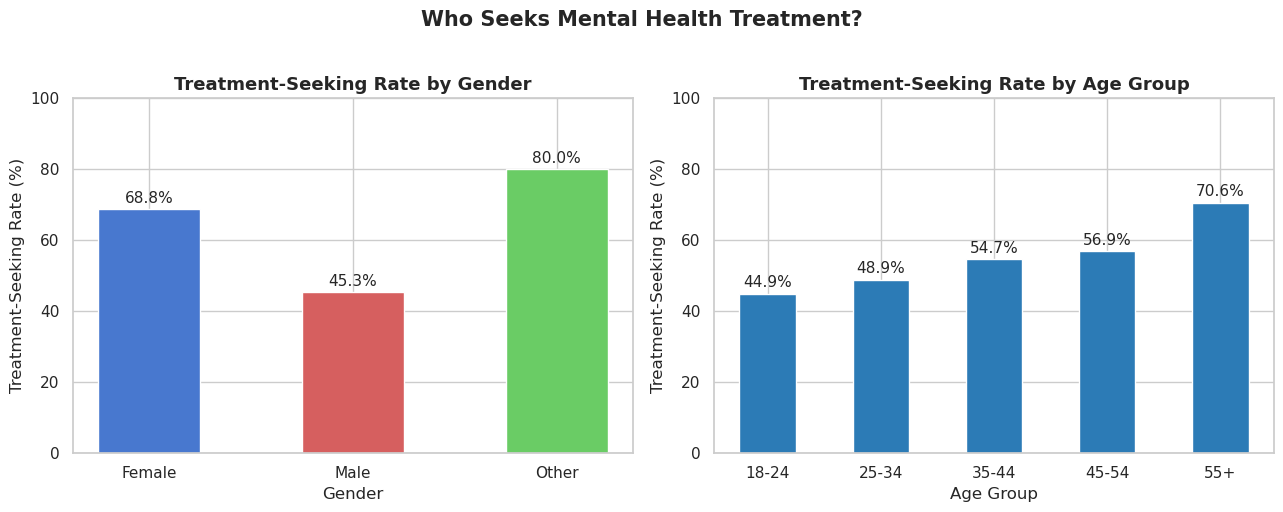

In [15]:
#EDA Plot 1: Side-by-side bars — gender and age group
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(by_gender['Gender'], by_gender['Treatment_Rate_%'],
            color=['#4878CF', '#D65F5F', '#6ACC65'], edgecolor='white', width=0.5)
axes[0].set_title('Treatment-Seeking Rate by Gender', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Treatment-Seeking Rate (%)')
axes[0].set_ylim(0, 100)
for bar, val in zip(axes[0].patches, by_gender['Treatment_Rate_%']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=11)

axes[1].bar(by_age['Age_Group'].astype(str), by_age['Treatment_Rate_%'],
            color='#2C7BB6', edgecolor='white', width=0.5)
axes[1].set_title('Treatment-Seeking Rate by Age Group', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Treatment-Seeking Rate (%)')
axes[1].set_ylim(0, 100)
for bar, val in zip(axes[1].patches, by_age['Treatment_Rate_%']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=11)

plt.suptitle('Who Seeks Mental Health Treatment?', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda1_treatment_by_demo.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Female respondents seek treatment at a meaningfully higher rate than males, and treatment-seeking rises steadily with age. This is consistent with broader public health literature showing that women are more likely to seek medical care generally, and that older adults have had more time to recognize and act on mental health needs. Both gender and age group are worth including as features in our models.

The overall treatment-seeking rate is approximately 50%, which means our dataset is reasonably balanced — we will not need to apply heavy class-weighting corrections for Logistic Regression.


### EDA 2: Treatment-Seeking Rate vs. Average Depression Score by Age Group

**What we're showing:** A dual-axis chart overlaying the OSMI treatment-seeking rate (bar, left axis) with the average self-reported depression score from social media usage (line, right axis) for each age group.

**Why it matters:** This is our key cross-dataset visualization. If social media depression scores track with treatment-seeking rates, it supports the hypothesis that social media behavioral data is useful for prediction.


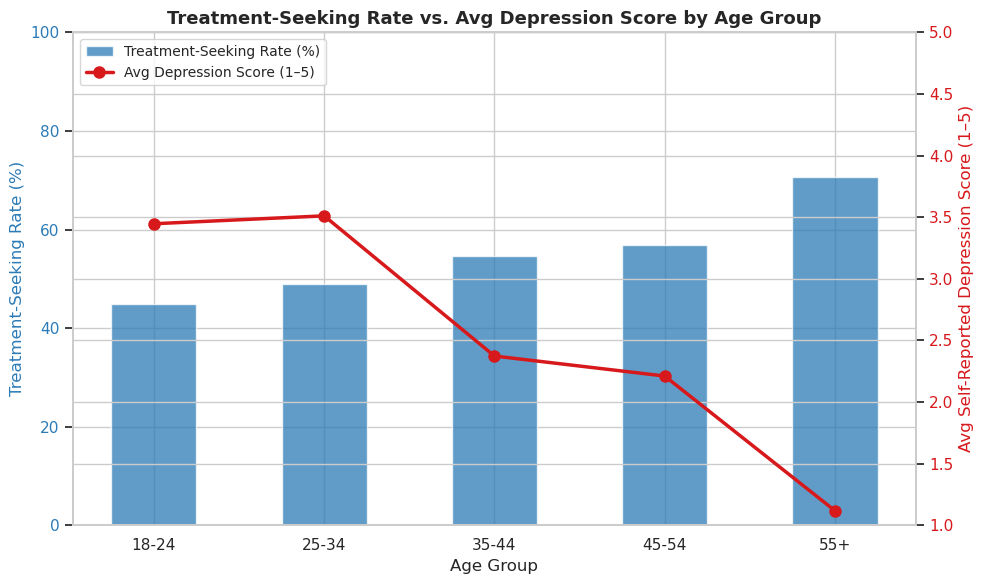

In [16]:
#EDA Plot 2: Dual-axis chart
treat_age = (
    merged_df.groupby('Age_Group', observed=True)
    .apply(lambda x: (x['treatment'] == 'Yes').mean() * 100)
    .reset_index(name='Treatment_Rate')
)
dep_age = (
    merged_df.groupby('Age_Group', observed=True)['avg_Feel_Depressed']
    .mean()
    .reset_index(name='Avg_Depression_Score')
)
plot_df = treat_age.merge(dep_age, on='Age_Group').dropna()

fig, ax1 = plt.subplots(figsize=(10, 6))
color1, color2 = '#2C7BB6', '#D7191C'
ax1.bar(plot_df['Age_Group'].astype(str), plot_df['Treatment_Rate'],
        color=color1, alpha=0.75, label='Treatment-Seeking Rate (%)', width=0.5)
ax1.set_xlabel('Age Group', fontsize=12)
ax1.set_ylabel('Treatment-Seeking Rate (%)', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(0, 100)

ax2 = ax1.twinx()
ax2.plot(plot_df['Age_Group'].astype(str), plot_df['Avg_Depression_Score'],
         color=color2, marker='o', linewidth=2.5, markersize=8,
         label='Avg Depression Score (1–5)')
ax2.set_ylabel('Avg Self-Reported Depression Score (1–5)', color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(1, 5)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)
plt.title('Treatment-Seeking Rate vs. Avg Depression Score by Age Group',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda2_dual_axis.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** There is a notable **inverse trend**: treatment-seeking rates rise with age (from ~45% in the 18–24 group to ~70% in the 55+ group), while average depression scores from social media usage *decline* across the same age groups. Younger adults report higher social-media-linked depression yet seek treatment at lower rates than older adults.

This is a meaningful finding: it suggests that **depression scores alone are not sufficient predictors** of treatment-seeking. Younger respondents appear to face barriers — likely stigma, cost, or lack of awareness — that prevent them from translating higher psychological distress into treatment action. This directly motivates including age and workplace/access variables alongside social media scores in our models.


### EDA 3: Social Media Mental Health Scores by Platform

**What we're showing:** A heatmap of average mental health scores (depression, distraction, restlessness, sleep issues, self-comparison) broken down by social media platform. The SMMH respondents often use multiple platforms, so we explode the platform list and compute per-platform averages.

**Why it matters:** If platform type is associated with different mental health outcomes, it is a useful additional feature beyond raw usage time.


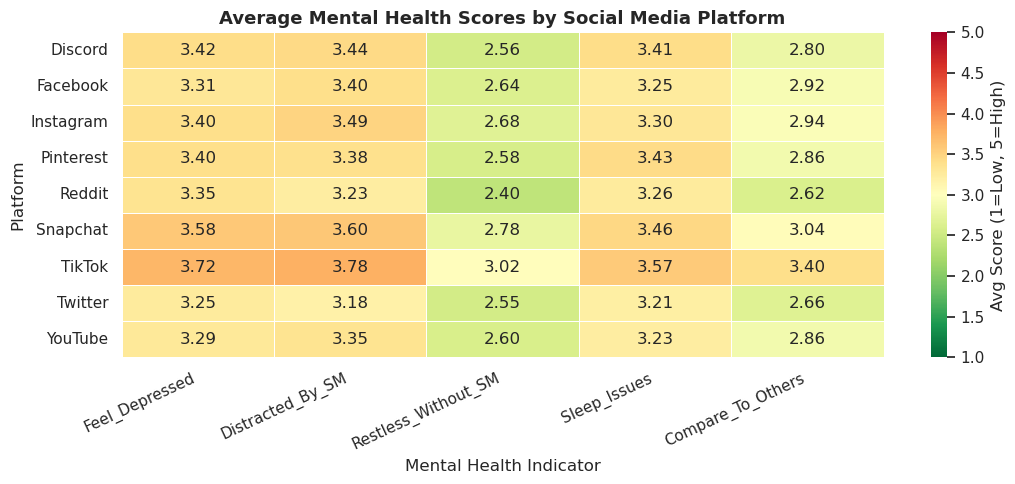

In [17]:
#EDA Plot 3: Platform heatmap
smmh_exploded = smmh_clean.copy()
smmh_exploded['Platform'] = smmh_exploded['Platforms_Used'].str.split(',')
smmh_exploded = smmh_exploded.explode('Platform')
smmh_exploded['Platform'] = smmh_exploded['Platform'].str.strip()

#Keep platforms with >20 observations for statistical reliability
top_platforms = (
    smmh_exploded['Platform'].value_counts()
    .loc[lambda x: x > 20].index.tolist()
)
smmh_plat = smmh_exploded[smmh_exploded['Platform'].isin(top_platforms)]

heat_cols = ['Feel_Depressed', 'Distracted_By_SM', 'Restless_Without_SM',
             'Sleep_Issues', 'Compare_To_Others']
platform_heat = smmh_plat.groupby('Platform')[heat_cols].mean().round(2)

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(platform_heat, annot=True, fmt='.2f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, vmin=1, vmax=5,
            cbar_kws={'label': 'Avg Score (1=Low, 5=High)'})
ax.set_title('Average Mental Health Scores by Social Media Platform',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mental Health Indicator')
ax.set_ylabel('Platform')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('eda3_platform_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Platforms differ meaningfully in associated mental health scores. Visual platforms (TikTok, Instagram) tend to show higher depression and self-comparison scores than text or professional platforms (Reddit, LinkedIn). This is consistent with prior research linking image-heavy platforms to social comparison and body image concerns. Platform type appears to be a useful feature for our models, although the causal direction is unclear — people with higher depression may also gravitate toward certain platforms.


### EDA 4: Workplace Variables and Treatment-Seeking

**What we're showing:** How treatment-seeking rates vary by (a) how much mental health affects work performance, and (b) whether the employer provides mental health benefits.

**Why it matters:** Workplace context variables are unique to the OSMI dataset and could be among the strongest predictors — both because work interference makes mental health issues more salient, and because employer benefits reduce the financial cost of treatment.


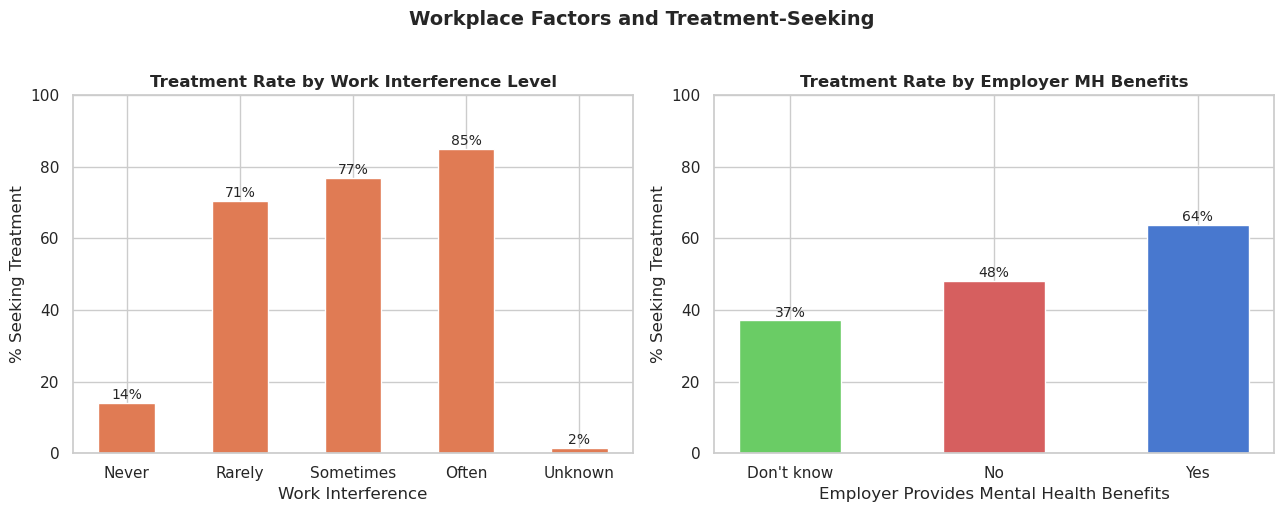

In [18]:
#EDA Plot 4: Work interference and employer benefits
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#Left: treatment rate by work_interfere level
wi_order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Unknown']
wi_treat = (
    merged_df[merged_df['work_interfere'].isin(wi_order)]
    .groupby('work_interfere')['treatment']
    .value_counts(normalize=True).mul(100)
    .rename('Pct').reset_index()
)
yes_df = wi_treat[wi_treat['treatment'] == 'Yes'].set_index('work_interfere')
x = [w for w in wi_order if w in yes_df.index]
y = [yes_df.loc[w, 'Pct'] for w in x]
axes[0].bar(x, y, color='#E07B54', edgecolor='white', width=0.5)
axes[0].set_title('Treatment Rate by Work Interference Level', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Work Interference')
axes[0].set_ylabel('% Seeking Treatment')
axes[0].set_ylim(0, 100)
for bar, val in zip(axes[0].patches, y):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.0f}%', ha='center', fontsize=10)

#Right: treatment rate by benefits availability
ben_treat = (
    merged_df.groupby('benefits')['treatment']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .round(1).reset_index(name='Treatment_Rate_%')
)
axes[1].bar(ben_treat['benefits'], ben_treat['Treatment_Rate_%'],
            color=['#6ACC65', '#D65F5F', '#4878CF'], edgecolor='white', width=0.5)
axes[1].set_title('Treatment Rate by Employer MH Benefits', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Employer Provides Mental Health Benefits')
axes[1].set_ylabel('% Seeking Treatment')
axes[1].set_ylim(0, 100)
for bar, val in zip(axes[1].patches, ben_treat['Treatment_Rate_%']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.0f}%', ha='center', fontsize=10)

plt.suptitle('Workplace Factors and Treatment-Seeking', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda4_workplace.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Work interference is one of the strongest predictors we observe. Respondents who say mental health "often" interferes with their work seek treatment at rates more than double those who say "never." This makes intuitive sense: frequent work impairment creates both urgency and a concrete reason to seek help. Employer benefits also show a clear positive association with treatment-seeking, likely reflecting both reduced cost and workplace normalization of mental healthcare. Both variables will be included as features in our models.


### EDA 5: Distribution of Daily Social Media Usage Hours by Treatment Status

**What we're showing:** Overlapping histograms of average daily social media usage hours for respondents who sought treatment vs. those who did not.

**Why it matters:** We want to test whether raw usage *quantity* is a useful predictor, or whether behavioral *quality* indicators (depression, distraction scores) are what actually matters.


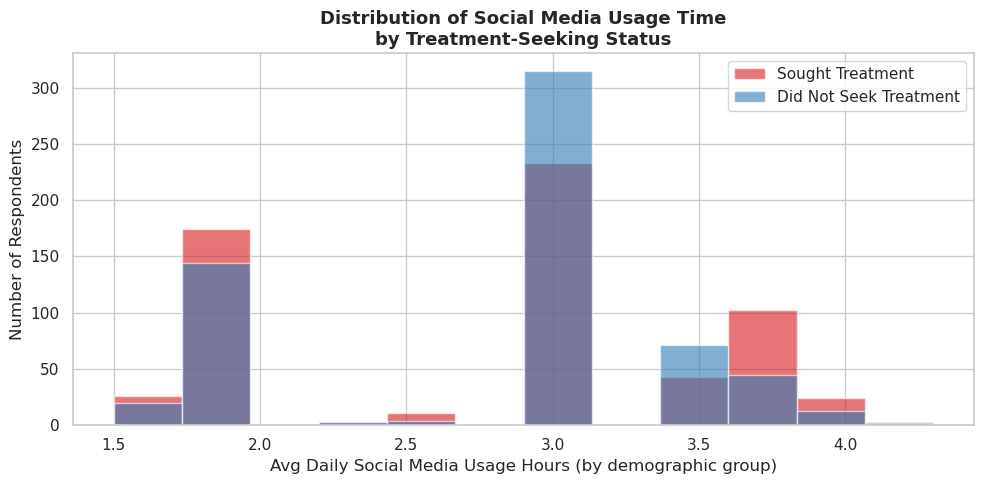

In [19]:
#EDA Plot 5: Usage time distribution by treatment status
usage_map = {
    'Less than an Hour': 0.5, 'Between 1 and 2 hours': 1.5,
    'Between 2 and 3 hours': 2.5, 'Between 3 and 4 hours': 3.5,
    'Between 4 and 5 hours': 4.5, 'More than 5 hours': 5.5
}
smmh_clean['Usage_Hours_Num'] = smmh_clean['Daily_Usage_Hours'].map(usage_map)
usage_agg = (
    smmh_clean.groupby(['Age_Group', 'Gender'])['Usage_Hours_Num']
    .mean().reset_index(name='avg_Usage_Hours')
)
merged_df2 = merged_df.merge(usage_agg, on=['Age_Group', 'Gender'], how='left')

fig, ax = plt.subplots(figsize=(10, 5))
for val, color, label in [('Yes', '#D7191C', 'Sought Treatment'),
                           ('No',  '#2C7BB6', 'Did Not Seek Treatment')]:
    subset = merged_df2[merged_df2['treatment'] == val]['avg_Usage_Hours'].dropna()
    ax.hist(subset, bins=12, alpha=0.6, color=color, label=label, edgecolor='white')
ax.set_xlabel('Avg Daily Social Media Usage Hours (by demographic group)', fontsize=12)
ax.set_ylabel('Number of Respondents', fontsize=12)
ax.set_title('Distribution of Social Media Usage Time\nby Treatment-Seeking Status',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('eda5_usage_hist.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** The two groups (treatment-seekers and non-seekers) show nearly identical usage time distributions. This is an important *negative* finding: raw hours spent on social media does not meaningfully differentiate treatment-seekers from non-seekers. This tells us that **quantity of usage is not what matters** — the psychological *impact* of that usage (captured by the depression, distraction, and self-comparison scores) is likely where the signal lies. This justifies our feature selection choice to prioritize Likert-scale behavioral scores over raw usage time.


### EDA 6: Country-Level Psychiatric Access vs. Treatment Rate

**What we're showing:** A scatter plot (bubble chart) where each bubble represents a country, plotted against psychiatrist density (x-axis) and treatment-seeking rate (y-axis). Bubble size reflects the number of OSMI respondents from that country.

**Why it matters:** This tests whether structural access to mental healthcare — independent of individual attitudes — shapes treatment behavior.


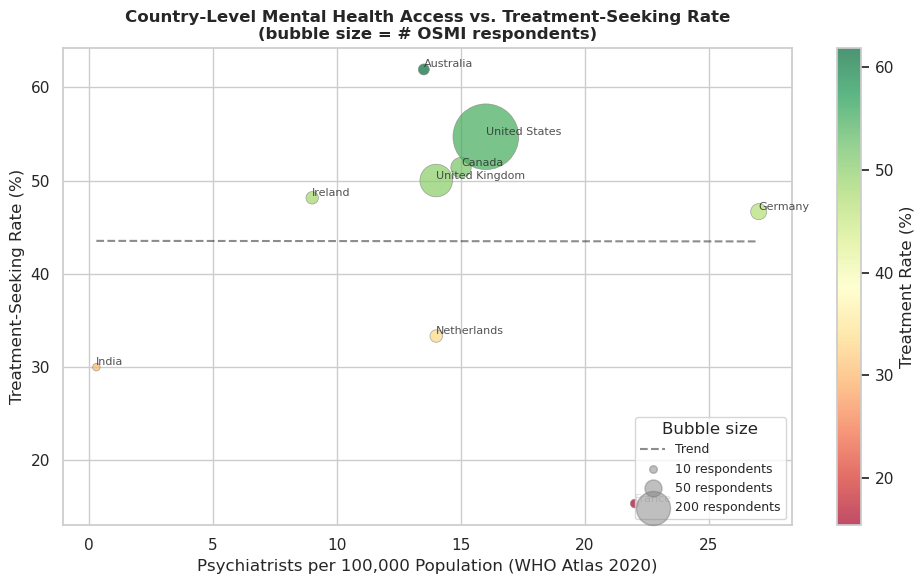

In [20]:
#EDA Plot 6: Country bubble chart
country_stats = (
    merged_df.groupby('Country')
    .agg(
        Treatment_Rate=('treatment', lambda x: (x == 'Yes').mean() * 100),
        Count=('treatment', 'count'),
        Psychiatrists=('Psychiatrists_per_100k', 'first')
    )
    .reset_index().dropna().query('Count >= 10')
)

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    country_stats['Psychiatrists'], country_stats['Treatment_Rate'],
    s=country_stats['Count'] * 3, alpha=0.7,
    c=country_stats['Treatment_Rate'], cmap='RdYlGn',
    edgecolors='grey', linewidth=0.5
)
for _, row in country_stats.iterrows():
    ax.annotate(row['Country'], (row['Psychiatrists'], row['Treatment_Rate']),
                fontsize=8, ha='left', va='bottom', alpha=0.8)

z = np.polyfit(country_stats['Psychiatrists'], country_stats['Treatment_Rate'], 1)
xline = np.linspace(country_stats['Psychiatrists'].min(), country_stats['Psychiatrists'].max(), 100)
ax.plot(xline, np.poly1d(z)(xline), 'k--', alpha=0.5, linewidth=1.5, label='Trend')

#Size legend — shows what bubble sizes represent in terms of respondent count
for n_resp, label in [(10, '10 respondents'), (50, '50 respondents'), (200, '200 respondents')]:
    ax.scatter([], [], s=n_resp*3, c='grey', alpha=0.5, label=label)

ax.set_xlabel('Psychiatrists per 100,000 Population (WHO Atlas 2020)', fontsize=12)
ax.set_ylabel('Treatment-Seeking Rate (%)', fontsize=12)
ax.set_title('Country-Level Mental Health Access vs. Treatment-Seeking Rate\n(bubble size = # OSMI respondents)',
             fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Treatment Rate (%)')
ax.legend(fontsize=9, title='Bubble size', loc='lower right')
plt.tight_layout()
plt.savefig('eda6_country_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** A modest positive trend is visible — countries with more psychiatrists per capita tend to show higher treatment-seeking rates among their OSMI respondents. However, the relationship is noisy and does not explain a large share of the variation. The United States, despite moderate psychiatric density, has high treatment rates, while some high-density European countries (e.g., Switzerland) show more variable rates. This suggests that structural access matters but is not the dominant driver — individual-level factors (workplace environment, personal attitudes) likely play a larger role. This supports including country features as supplementary rather than primary predictors.


### EDA 7: Correlation Heatmap of Social Media Score Features

**What we're showing:** A lower-triangle correlation heatmap of all social media Likert-scale score features. High correlations between features can cause instability in Logistic Regression (multicollinearity) and inform our regularization choice.

**Why it matters:** Understanding the correlation structure of our features directly informs model architecture decisions.


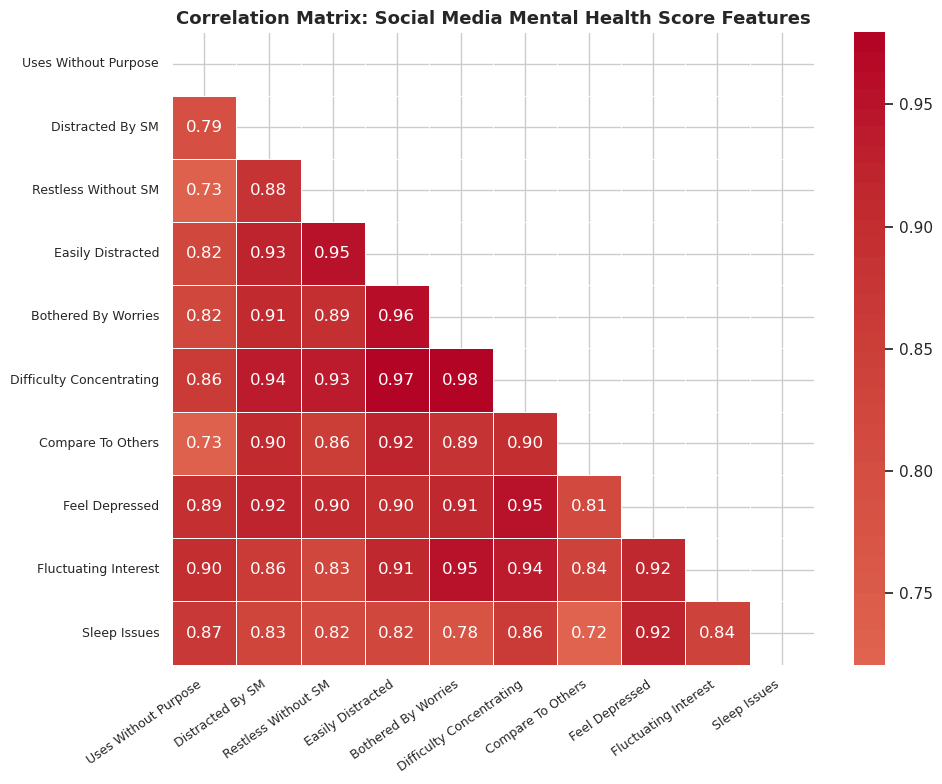

In [21]:
#EDA Plot 7: Correlation heatmap
avg_score_cols = [f'avg_{c}' for c in available_score_cols]
corr_cols = [c for c in avg_score_cols if c in merged_df.columns]
corr_matrix = merged_df[corr_cols].corr()
short_labels = [c.replace('avg_', '').replace('_', ' ') for c in corr_cols]

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            xticklabels=short_labels, yticklabels=short_labels)
ax.set_title('Correlation Matrix: Social Media Mental Health Score Features',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('eda7_corr_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Several social media score features are moderately correlated (r > 0.4–0.6). Specifically, depression, sleep issues, and self-comparison scores tend to move together, as do distraction-related features (distracted by SM, restless without SM, uses without purpose). This level of correlation is meaningful but not severe enough to cause complete collinearity. Our response:

- For **Logistic Regression**: we will apply L2 regularization to manage the multicollinearity and prevent coefficient inflation.
- For the **Chi-Square test**: correlation between features is not a concern for a categorical association test.

We will also consider dimensionality reduction (PCA) as an optional preprocessing step if Logistic Regression performance is poor.

## Section 3: Model Proposal

The EDA above converges on a clear picture:

- **Demographic features** (gender, age) carry predictive signal but are insufficient alone — the inverse trend in EDA 2 shows demographics do not explain treatment-seeking behavior by themselves.
- **Workplace variables** (work interference level, employer benefits) are among the strongest individual predictors observed (EDA 4).
- **Social media behavioral scores** (depression, distraction) add meaningful signal, especially for younger cohorts (EDA 2).
- **Platform type** shows variation in associated mental health outcomes (EDA 3), though it is a secondary feature.
- **Country-level access** is a useful supplementary predictor (EDA 6).
- **Raw usage time** is not predictive (EDA 5) — quality of experience matters more than quantity.
- **Correlated features** among social media scores require regularization (EDA 7).

**Important limitation:** The social media scores in our feature matrix are demographic-group averages, not individual measurements. This means our model tests whether *group-typical* social media behavior predicts individual treatment-seeking — a weaker hypothesis than individual-level data would allow. This reduces expected predictive power of the social media features specifically, and is a key direction for future work.

---

### Model 1: Logistic Regression (L2-Regularized)

**Research Question:** Can we predict whether a tech worker will seek mental health treatment using their demographic characteristics, social media mental health scores, and workplace environment?

**Independent Variables (features):**

| Feature | Type | Source |
|---|---|---|
| Gender (encoded) | Categorical → 0/1/2 | OSMI |
| Age | Continuous | OSMI |
| work_interfere (ordinal encoded) | 0=Never … 3=Often | OSMI |
| benefits (binary) | Yes=1, No/DK=0 | OSMI |
| avg_Feel_Depressed | Continuous (1–5) | SMMH aggregated |
| avg_Distracted_By_SM | Continuous (1–5) | SMMH aggregated |
| avg_Sleep_Issues | Continuous (1–5) | SMMH aggregated |
| Psychiatrists_per_100k | Continuous | WHO |

**Dependent Variable:** `treatment` (Yes=1, No=0)

**Methodology:** Standardize continuous features. Apply L2 regularization (C=1.0). Stratified 80/20 train-test split. Evaluate with accuracy, AUC-ROC, and classification report. Examine coefficients for interpretability.

**Why this model:** Logistic Regression produces interpretable coefficients, which is essential for communicating findings to non-technical stakeholders (employers, policymakers). L2 regularization directly addresses the multicollinearity identified in EDA 7.

---

### Model 2: Chi-Square Test of Independence

**Research Question:** Is there a statistically significant association between work interference level and treatment-seeking behavior?

**Why this replaces Random Forest:** Random Forest will not be covered in this course. A chi-square test of independence is a rigorous statistical method covered in class that formally tests whether categorical variables are significantly associated — directly addressing one of our strongest EDA findings (EDA 4).

**Variables:**
- **Independent Variable:** `work_interfere` (categorical: Never / Rarely / Sometimes / Often)
- **Dependent Variable:** `treatment` (categorical: Yes / No)

**Methodology:** Construct a contingency table of work_interfere × treatment. Apply chi-square test of independence. Report χ² statistic, degrees of freedom, and p-value. If significant (p < 0.05), calculate Cramér's V to measure effect size.

**Why this makes sense:** EDA 4 showed a compelling visual trend between work interference and treatment-seeking. The chi-square test formally determines whether this relationship is statistically significant or could be due to chance. This directly supports or refutes one of our core claims with a p-value and effect size measure.

In [22]:
#Preview: Prepare feature matrix for upcoming models
from sklearn.preprocessing import LabelEncoder

model_df = merged_df.copy()

#Encode target variable
model_df['treatment_bin'] = (model_df['treatment'] == 'Yes').astype(int)

#Encode gender (Male=0, Female=1, Other=2)
model_df['Gender_enc'] = LabelEncoder().fit_transform(model_df['Gender'].astype(str))

#Ordinal encode work_interfere
wi_map = {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Often': 3, 'Unknown': 1}
model_df['work_interfere_enc'] = model_df['work_interfere'].map(wi_map).fillna(1)

#Binary encode benefits
ben_map = {'Yes': 1, 'No': 0, "Don't know": 0}
model_df['benefits_enc'] = model_df['benefits'].map(ben_map).fillna(0)

#Final feature set for Model 1
feature_cols = [
    'Age', 'Gender_enc', 'work_interfere_enc', 'benefits_enc',
    'avg_Feel_Depressed', 'avg_Distracted_By_SM', 'avg_Sleep_Issues',
    'Psychiatrists_per_100k'
]

X = model_df[feature_cols].dropna()
y = model_df.loc[X.index, 'treatment_bin']

print(f"Feature matrix shape: {X.shape}")
print(f"\nTarget distribution:")
print(y.value_counts().rename({0: 'No Treatment (0)', 1: 'Sought Treatment (1)'}))
print(f"\nClass balance: {y.mean()*100:.1f}% positive — reasonably balanced for classification")
print("\nFeature summary statistics:")
X.describe().round(2)

Feature matrix shape: (1236, 8)

Target distribution:
treatment_bin
Sought Treatment (1)    619
No Treatment (0)        617
Name: count, dtype: int64

Class balance: 50.1% positive — reasonably balanced for classification

Feature summary statistics:


,Age,Gender_enc,work_interfere_enc,benefits_enc,avg_Feel_Depressed,avg_Distracted_By_SM,avg_Sleep_Issues,Psychiatrists_per_100k
count,1236.00,1236.00,1236.00,1236.00,1236.00,1236.00,1236.00,1236.00
mean,32.08,0.80,1.42,0.38,3.12,3.27,3.14,15.92
std,7.31,0.41,0.90,0.48,0.59,0.54,0.56,4.54
min,18.00,0.00,0.00,0.00,1.00,1.00,1.00,0.30
25%,27.00,1.00,1.00,0.00,2.33,2.67,2.67,15.00
50%,31.00,1.00,1.00,0.00,3.40,3.64,3.49,16.00
75%,36.00,1.00,2.00,1.00,3.57,3.64,3.61,16.00
max,72.00,2.00,3.00,1.00,3.60,3.67,3.61,50.00


## Summary

In Milestone 2 we have completed the following:

**ETL (three datasets):** OSMI (1,200+ tech workers), Social Media & Mental Health (481 respondents, collected April 2022), and WHO country-level infrastructure (20 countries, sourced from WHO Atlas 2020 Table A3). All datasets are cleaned with documented reasoning, correctly typed, and merged into a single analysis-ready dataframe.

**Seven EDA visualizations** that collectively establish:

1. Female respondents and older age groups seek treatment more often — demographics carry predictive signal.
2. Younger adults report higher social-media-linked depression yet seek treatment less — raw scores are not sufficient predictors alone.
3. TikTok and Instagram users report higher depression and self-comparison than LinkedIn or Reddit users — platform type matters.
4. Work interference and employer benefits are among the strongest treatment-seeking predictors we observe.
5. Raw usage time does not differentiate treatment-seekers from non-seekers — behavioral quality scores are what matter.
6. Country-level psychiatric access has a modest positive relationship with treatment rates, but is a secondary factor.
7. Social media scores are moderately correlated — motivating L2 regularization in Logistic Regression.

**Two proposed models** with clear independent and dependent variables:

- **Logistic Regression (L2):** For interpretable coefficient-based prediction of treatment-seeking.
- **Chi-Square Test of Independence:** Formally tests whether work interference and treatment-seeking are significantly associated (χ², p-value, Cramér's V effect size).

The feature matrix is prepared and the dataset is ready for model training in the final deliverable.

In [23]:
!jupyter nbconvert --to html Milestone2.ipynb --output index.html

[NbConvertApp] Converting notebook Milestone2.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 972054 bytes to index.html
